In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import clickhouse_connect
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
print("✅ Imports OK")

✅ Imports OK


In [14]:
client = clickhouse_connect.get_client(
    host='clickhouse', port=8123,
    user='default', password='clickhouse123',
    database='gold'
)

df = client.query_df("""
SELECT
    d.Year                              AS year,
    d.Month                             AS month,
    d.Quarter                           AS quarter,
    SUM(f.LinePrice)                    AS total_sales,
    SUM(f.Quantity)                     AS total_quantity,
    COUNT(DISTINCT f.DocumentCode)      AS nb_documents,
    COUNT(DISTINCT f.ClientSK)          AS nb_clients,
    COUNT(DISTINCT f.ItemSK)            AS nb_produits,
    COUNT(DISTINCT f.GeographicalAreaSK) AS nb_regions,
    COUNT(DISTINCT f.WarehouseSK)       AS nb_warehouses,
    AVG(f.DiscountPercentage)           AS avg_discount,
    SUM(f.DiscountAmount)               AS total_discount,
    SUM(f.CostPrice)                    AS total_cost,
    SUM(f.LinePrice - f.CostPrice)      AS total_marge
FROM gold.fact_sales AS f
JOIN gold.dim_date AS d ON f.DateSK = d.DateSK
WHERE f.DocumentTypeSK IN (4, 1, 5)
  AND f.LinePrice IS NOT NULL
GROUP BY year, month, quarter
ORDER BY year, month
""")

df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
print(f"✅ {len(df)} mois chargés")
df.head()
df.shape

✅ 51 mois chargés


(51, 15)

In [15]:
print(f"Avant nettoyage : {len(df)} mois")
print(f"Mois incomplets :")
print(df[
    (df['date'] < '2022-01-01') | (df['date'] >= '2026-02-01')
][['date', 'total_sales']].to_string(index=False))

df = df[
    (df['date'] >= '2022-01-01') & (df['date'] < '2026-02-01')
].reset_index(drop=True)

print(f"\nAprès nettoyage : {len(df)} mois")
print(f"Période : {df['date'].min().strftime('%b %Y')} → {df['date'].max().strftime('%b %Y')}")

Avant nettoyage : 51 mois
Mois incomplets :
      date  total_sales
2021-03-01       404.06
2026-02-01   114,247.11

Après nettoyage : 49 mois
Période : Jan 2022 → Jan 2026


In [16]:
# Variables directement disponibles sans feature engineering complexe
# On garde ce qui est métier-pertinent et statistiquement corrélé à total_sales

df_ml = df[[
    'date',
    'year',
    'month',
    'quarter',
    'total_sales',      # ← TARGET
]].copy()

# Variables temporelles simples
df_ml['semester'] = df_ml['month'].apply(lambda x: 1 if x <= 6 else 2)
df_ml['is_summer']   = df_ml['month'].isin([7, 8]).astype(int)
df_ml['is_end_year'] = df_ml['month'].isin([11, 12]).astype(int)
df_ml['is_january']  = (df_ml['month'] == 1).astype(int)

# Lag features — uniquement les plus pertinents
df_ml['lag_1']  = df_ml['total_sales'].shift(1)
df_ml['lag_12'] = df_ml['total_sales'].shift(12)  # même mois année précédente
df_ml['rolling_mean_3'] = df_ml['total_sales'].shift(1).rolling(3).mean()

# Supprimer les NaN dus aux lags
df_ml = df_ml.dropna().reset_index(drop=True)

print(f"✅ Dataset prêt : {df_ml.shape}")
print(f"Période : {df_ml['date'].min().strftime('%b %Y')} → {df_ml['date'].max().strftime('%b %Y')}")
df_ml.head()

✅ Dataset prêt : (37, 15)
Période : Jan 2023 → Jan 2026


,date,year,month,quarter,total_sales,total_quantity,nb_documents,nb_clients,semester,is_summer,is_end_year,is_january,lag_1,lag_12,rolling_mean_3
0,2023-01-01,2023,1,1,"1,037,923.46",16598,1380,223,1,0,0,1,"985,659.74","591,407.94","960,005.64"
1,2023-02-01,2023,2,1,"939,044.09",15537,1280,227,1,0,0,0,"1,037,923.46","576,097.45","993,566.44"
2,2023-03-01,2023,3,1,"948,325.78",15961,1392,240,1,0,0,0,"939,044.09","680,213.89","987,542.43"
3,2023-04-01,2023,4,2,"913,161.55",17831,1237,235,1,0,0,0,"948,325.78","650,789.55","975,097.78"
4,2023-05-01,2023,5,2,"1,184,666.29",20290,1514,246,1,0,0,0,"913,161.55","734,335.68","933,510.47"


In [17]:
from sklearn.feature_selection import RFE, SequentialFeatureSelector
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# Toutes les features candidates
ALL_FEATURES = [
    'month', 'quarter', 'semester',
    'total_quantity', 'nb_documents', 'nb_clients',
    'nb_produits', 'nb_regions', 'avg_discount',
    'total_discount', 'total_cost', 'total_marge',
    'is_summer', 'is_end_year', 'is_january',
    'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12',
    'rolling_mean_3', 'rolling_mean_6', 'rolling_std_3',
    'rolling_max_3', 'rolling_min_3',
    'growth_1m', 'growth_yoy'
]
TARGET = 'total_sales'
# Garder uniquement les colonnes existantes dans df_ml
ALL_FEATURES = [f for f in ALL_FEATURES if f in df_ml.columns]

X_all = df_ml[ALL_FEATURES]
y_all = df_ml[TARGET]

# Split temporel
split_idx    = int(len(df_ml) * 0.9)
X_tr, X_te   = X_all.iloc[:split_idx], X_all.iloc[split_idx:]
y_tr, y_te   = y_all.iloc[:split_idx], y_all.iloc[split_idx:]

scaler    = StandardScaler()
X_tr_sc   = scaler.fit_transform(X_tr)
X_te_sc   = scaler.transform(X_te)

print(f"✅ {len(ALL_FEATURES)} features candidates")
print(ALL_FEATURES)

✅ 12 features candidates
['month', 'quarter', 'semester', 'total_quantity', 'nb_documents', 'nb_clients', 'is_summer', 'is_end_year', 'is_january', 'lag_1', 'lag_12', 'rolling_mean_3']


✅ Features candidates (9) :
  • month
  • quarter
  • semester
  • is_summer
  • is_end_year
  • is_january
  • lag_1
  • lag_12
  • rolling_mean_3


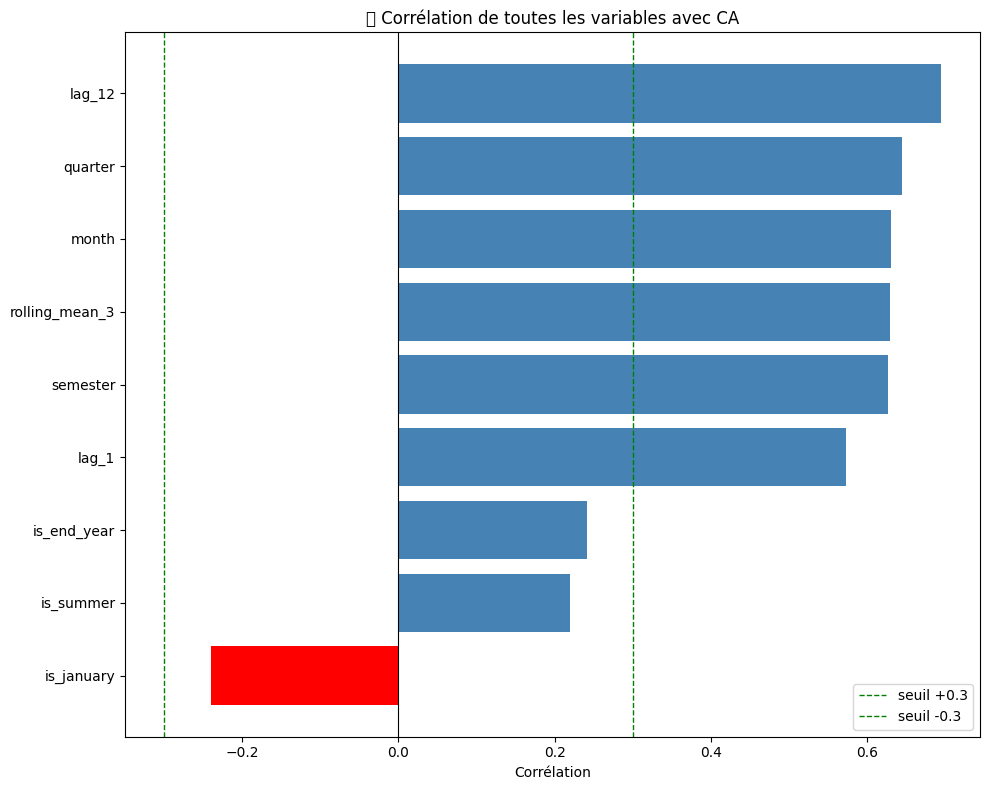


Corrélations triées :
is_january       -0.24
is_summer         0.22
is_end_year       0.24
lag_1             0.57
semester          0.63
rolling_mean_3    0.63
month             0.63
quarter           0.64
lag_12            0.69


In [18]:
CONTEMPORAINES = [
    'total_quantity', 'nb_produits', 'nb_clients',
    'nb_documents', 'nb_regions', 'nb_warehouses',
    'avg_discount', 'total_discount', 'total_cost', 'total_marge'
]

ALL_COLS = [c for c in df_ml.columns
                if c not in [
                    'date', 'year', TARGET,
                    'growth_1m', 'growth_yoy',
                ] + CONTEMPORAINES]

print(f"✅ Features candidates ({len(ALL_COLS)}) :")
for f in ALL_COLS:
    print(f"  • {f}")

# Calculer corrélation avec target
corr = df_ml[ALL_COLS + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

# Visualiser
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['red' if v < 0 else 'steelblue' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(0.3,  color='green', linewidth=1, linestyle='--', label='seuil +0.3')
ax.axvline(-0.3, color='green', linewidth=1, linestyle='--', label='seuil -0.3')
ax.set_title('📊 Corrélation de toutes les variables avec CA')
ax.set_xlabel('Corrélation')
ax.legend()
plt.tight_layout()
plt.show()

print("\nCorrélations triées :")
print(corr.to_string())

In [19]:
# Garder uniquement |corrélation| > 0.3
threshold = 0.3
selected_corr = corr[abs(corr) > threshold].index.tolist()

print(f"✅ Variables sélectionnées par corrélation ({len(selected_corr)}) :")
for f in selected_corr:
    print(f"  • {f:<25} corr = {corr[f]:.3f}")

FEATURES_CORR = selected_corr
X = df_ml[FEATURES_CORR]
y = df_ml[TARGET]

✅ Variables sélectionnées par corrélation (6) :
  • lag_1                     corr = 0.572
  • semester                  corr = 0.627
  • rolling_mean_3            corr = 0.629
  • month                     corr = 0.630
  • quarter                   corr = 0.644
  • lag_12                    corr = 0.695


In [20]:
import json

df_ml.to_csv('/app/notebooks/ml_dataset_tst.csv', index=False)
with open('/app/notebooks/features_tst.json', 'w') as f:
    json.dump(FEATURES_CORR, f)

print(f"✅ Dataset sauvegardé → {df_ml.shape}")
print(f"✅ Features corrélation → {FEATURES_CORR}")

✅ Dataset sauvegardé → (37, 15)
✅ Features corrélation → ['lag_1', 'semester', 'rolling_mean_3', 'month', 'quarter', 'lag_12']
